# Hands-on: Run inference on a Toy SST model

This notebook describes how to run inference of in anemoi from an existing checkpoint. It is an overly simple model, with very limited inputs, and very limited compute. It is not expected to perform well, and users should not expect skillful results, instead the intent is to play around with how the model works.

**Resources:**

[anemoi-inference](https://anemoi-inference.readthedocs.io/en/latest/apis/level1.html) package.

## Setup

In [13]:
#ensure in the right dir if not already
current_dir = %pwd

if not current_dir.endswith("ToySSTProblem"):
    %cd ToySSTProblem

%pwd

'/home/student1/ToySSTProblem'

We need to ensure we are working in a suitable environment. Depending on your platform, this may already be set up for you. If it isn't, we have provided a requirements.txt file. This is compatible with python 3.11.10. To set your environment up, first load this version of python. Then install the required libraries with
```
pip install -r requirements.txt
```

In [14]:
#!/opt/conda/envs/ecmwf-ml/bin/python -m pip install -r requirements.txt

In [17]:
# Import the necessary modules

import os

import shutil
from pathlib import Path
import subprocess
import torch
import warnings
import copy
warnings.filterwarnings("ignore", category=UserWarning)

from anemoi.inference.checkpoint import Checkpoint
from anemoi.inference.runners.simple import SimpleRunner
from anemoi.inference.outputs.printer import print_state

import yaml
from omegaconf import OmegaConf
from pathlib import Path

import subprocess
import sys, os 

%matplotlib inline

#### Obtain data
If you have already run the training_ToySST notebook, you will have already obtained the data needed. And if working on EWC or Edito, you may already have access to the relevant data.  Otherwise, a tarball with output from a pre-trained model is available on S3 cloud storage. Pull this if required.

In [18]:
## First pull the output from a pre-trained model, and change permissions.
## This should create a directory "pretrained_outputs" containing checkpoints, logs and plots

NeedData = True

if NeedData:
    !curl -L https://object-store.os-api.cci1.ecmwf.int/ecmwf-training-nwp-ml/training_outputs.tgz | tar xz
    # rename to avoid confusion later
    old=Path("./training_outputs")
    new=Path("./pretrained_outputs")
    shutil.rmtree(new, ignore_errors=True)
    old.rename(new)
    old.mkdir(parents=True, exist_ok=True)
    shutil.copytree(new, old, dirs_exist_ok=True)
    shutil.rmtree(old, ignore_errors=True)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  684M  100  684M    0     0  86.8M      0  0:00:07  0:00:07 --:--:-- 86.4M


## Investigate the checkpoint

The model creates checkpoints throughout training. These contain the learned weights, which the model uses to make predictions, along with various metadata about the model.

We've provided a checkpoint from a trained model, based on the ToySST problem shown in the training_ToySST.ipynb notebook, but with a few changes (such as more channels in the model, larger batches and more epochs) to give the model better skill.

In [19]:
ckpt_file = "./pretrained_outputs/checkpoint/4438386d8b894aa59beb57bb1c7e0b85/inference-last.ckpt"

#### Investigate the checkpoint

We first see that the checkpoint contains all the relevant information about the required inputs for the model:

In [20]:
print("Loading checkpoint...")
ckpt = Checkpoint(ckpt_file)

# Variables used during training:
print("Number of variables:", len(ckpt.variable_categories()))
print(f"Diagnostic variables: {ckpt.diagnostic_variables}")
print(f"Prognostic variables: {ckpt.prognostic_variables}")

Old metadata format detected. Please update your weights.


Loading checkpoint...
Number of variables: 11
Diagnostic variables: []
Prognostic variables: ['sst']


/tmp/ipykernel_229075/3680675016.py:6: UnsupportedWarning: diagnostic_variables is unsupported as of 0.8.0. Use `select_variables` instead.
  print(f"Diagnostic variables: {ckpt.diagnostic_variables}")
/tmp/ipykernel_229075/3680675016.py:7: UnsupportedWarning: prognostic_variables is unsupported as of 0.8.0. Use `select_variables` instead.
  print(f"Prognostic variables: {ckpt.prognostic_variables}")


We can also probe the model architecture. Here we see the number of channels, the processor type etc. 

In [21]:
model = torch.load(ckpt.path, weights_only=False, map_location=torch.device('cpu'))
model

AnemoiModelInterface(
  (pre_processors): ModuleDict(
    (data): Processors [forward](ModuleDict(
      (normalizer): InputNormalizer()
      (const_imputer): ConstantImputer()
    ))
  )
  (post_processors): ModuleDict(
    (data): Processors [inverse](ModuleDict(
      (const_imputer): ConstantImputer()
      (normalizer): InputNormalizer()
    ))
  )
  (pre_processors_tendencies): ModuleDict()
  (post_processors_tendencies): ModuleDict()
  (model): AnemoiModelEncProcDec(
    (node_attributes): ModuleDict(
      (data): NamedNodesAttributes(
        (trainable_tensors): ModuleDict(
          (data): TrainableTensor()
          (hidden): TrainableTensor()
        )
      )
    )
    (encoder_graph_provider): ModuleDict(
      (data): StaticGraphProvider(
        (trainable): TrainableTensor()
      )
    )
    (encoder): ModuleDict(
      (data): GraphTransformerForwardMapper(
        (activation): GELU(approximate='none')
        (proc): GraphTransformerMapperBlock(
          (lin_k

We can also look at the total number of weights, i.e. the number of learnable parameters:

In [22]:
print(f"Number of weights: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Number of weights: 4676257


## Producing a forecast

Running the model for inference requires inputs. For our Toy SST example, these are initial conditions, and atmospheric inputs (the 2mT). We retrieve these input conditions from the same dataset that we used to train the model, this time taking dates from 2023, the validation period we defined in our training configuration (ToySST.yaml).

Here we make a single forecast, using anemoi-inference. The configuration file for anemoi inference is shown here. This defines the forecast set up, such as the date to begin the forecast, the forecast length, and where to obtain the forcing data.


In [23]:
# Load our minimal configuration file
config_path = Path("./inference_ToySST.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Inference Configuration:")
print("=" * 50)
print(yaml.dump(config, default_flow_style=False))

Inference Configuration:
checkpoint: ./training_outputs/checkpoint/4438386d8b894aa59beb57bb1c7e0b85/inference-last.ckpt
date: 2023-01-05
input:
  dataset:
    datasets: ./ToySSTDataset.zarr
    end: 2024-12-31
    start: 2020-01-01
lead_time: 360
output:
  tee:
    outputs:
    - truth:
        output:
          netcdf:
            path: Truth.nc
    - netcdf:
        path: Predictions.nc



We see the path to the checkpoint, which we inspected earlier. We see a start date of 5th January 2023. The 'input' command notes that we are predicting for the validation period within the dataset. We also give a lead time (here 15 days - 360 hours) and information on the output. Data can be output different data formats, including grib and netcdf. Here we tell anemoi-inference to 'tee' the output, and output the truth (i.e. a copy of the targets from the original zarr dataset) to the file `Truth.nc`, and output predictions to the file `Predicitons.nc`

### Run the forecast



Inference can easily be run on the command line with
```bash
anemoi-inference run config_name.yaml
```

Here we wrap the command for the notebook

In [27]:
# Execute the training using subprocess
print("Starting ML-ocean inference...")
print("=" * 50)

process = subprocess.Popen(
    [
        "anemoi-inference", "run", 
        "inference_ToySST.yaml"
    ], 
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # Merge stderr into stdout
    text=True,
    bufsize=1,  # Line buffered
    universal_newlines=True
)

# Stream output
for line in iter(process.stdout.readline, ''):
    if line:
        print(line.rstrip())  # Print immediately to Jupyter cell

# Wait for completion
return_code = process.wait()

print("=" * 50)
if return_code == 0:
    print("✓ Inference completed successfully!")
else:
    print(f"❌ Inference failed with return code {return_code}")

Starting ML-ocean inference...
2026-04-09 19:26:13 INFO Pre processors: []
2026-04-09 19:26:13 INFO Post processors: []
/opt/conda/envs/ecmwf-ml/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-04-09 19:26:14 INFO Using DefaultRunner runner, device=cuda
2026-04-09 19:26:14 INFO Loading multi-dataset metadata with dataset name `data`
2026-04-09 19:26:14 WARNING Old metadata format detected. Please update your weights.
2026-04-09 19:26:14 INFO Loading `config.prognostic_input` from `config.input`
2026-04-09 19:26:14 INFO Prognostic input: DatasetInput((), {'datasets': './ToySSTDataset.zarr', 'start': '2020-01-01', 'end': '2024-12-31'})
2026-04-09 19:26:14 INFO Output: TeeOutput([TruthOutput(NetCDFOutput(Truth.nc)), NetCDFOutput(Pr

# Inspect the generated forecast

### Plot a field

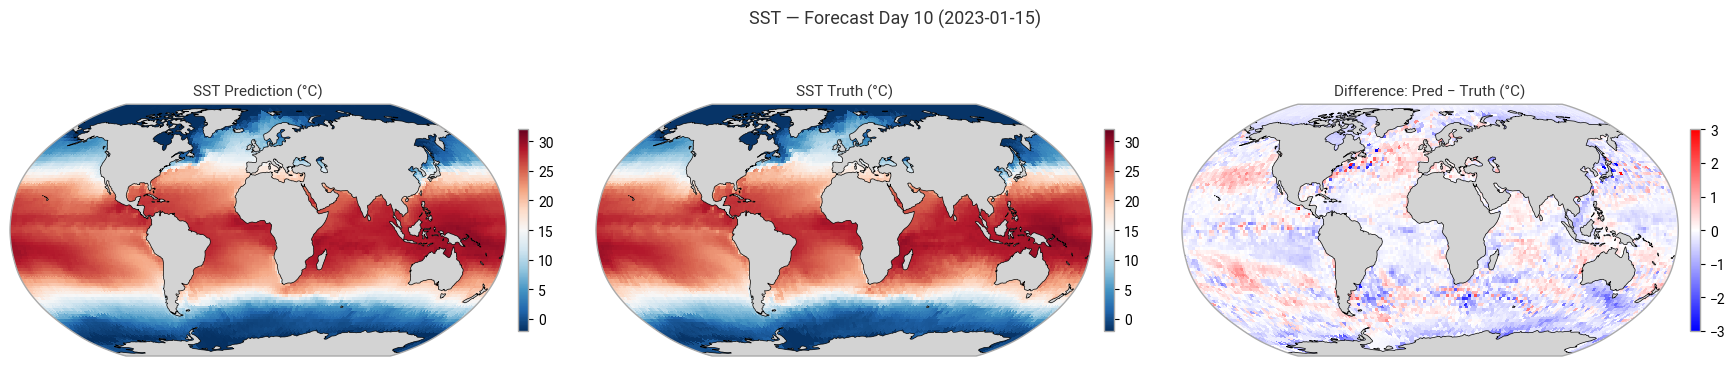

In [28]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
from scipy.interpolate import griddata

# Load predictions
ds_pred = nc.Dataset('./Predictions.nc')
times    = ds_pred.variables['time'][:]
lats     = ds_pred.variables['latitude'][:]
lons     = ds_pred.variables['longitude'][:]
sst_pred = ds_pred.variables['sst'][:]   # shape: (time, values), units: K
ds_pred.close()

# Load truth
ds_truth  = nc.Dataset('./Truth.nc')
sst_truth = ds_truth.variables['sst'][:]
ds_truth.close()

# Build forecast datetimes (base = 2023-01-05)
base_date      = datetime(2023, 1, 5)
forecast_dates = [base_date + timedelta(seconds=int(t)) for t in times]

# Regular grid for interpolation
lon_reg = np.linspace(0, 360, 720)
lat_reg = np.linspace(-90, 90, 360)
lon_grid, lat_grid = np.meshgrid(lon_reg, lat_reg)

def regrid(data_1d, lons, lats, lon_grid, lat_grid):
    """Interpolate unstructured ocean points onto a regular lon/lat grid."""
    valid = ~np.isnan(data_1d)
    return griddata(
        (lons[valid], lats[valid]), data_1d[valid],
        (lon_grid, lat_grid), method='nearest'
    )

# --- Spatial plot: forecast day 10 (3 panes: prediction, truth, difference) ---
day_idx   = 10
day_label = forecast_dates[day_idx].strftime('%Y-%m-%d')

pred_day  = sst_pred[day_idx]  - 273.15   # K -> °C
truth_day = sst_truth[day_idx] - 273.15
diff_day  = pred_day - truth_day

pred_grid  = regrid(pred_day,  lons, lats, lon_grid, lat_grid)
truth_grid = regrid(truth_day, lons, lats, lon_grid, lat_grid)
diff_grid  = regrid(diff_day,  lons, lats, lon_grid, lat_grid)

proj = ccrs.Robinson()
land  = cfeature.LAND
coast = cfeature.COASTLINE

fig, axes = plt.subplots(
    1, 3, figsize=(18, 4),
    subplot_kw={'projection': proj}
)

panels = [
    (pred_grid,  'RdBu_r', -2, 32, 'SST Prediction (°C)'),
    (truth_grid, 'RdBu_r', -2, 32, 'SST Truth (°C)'),
    (diff_grid,  'bwr',    -3,  3,  'Difference: Pred − Truth (°C)'),
]

for ax, (data, cmap, vmin, vmax, title) in zip(axes, panels):
    ax.set_global()
    mesh = ax.pcolormesh(
        lon_grid, lat_grid, data,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax.add_feature(land,  facecolor='lightgray', zorder=1)
    ax.add_feature(coast, linewidth=0.5, zorder=2)
    plt.colorbar(mesh, ax=ax, shrink=0.6, pad=0.02)
    ax.set_title(title, fontsize=11)

fig.suptitle(f'SST — Forecast Day 10 ({day_label})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Plot a forecast time-series 

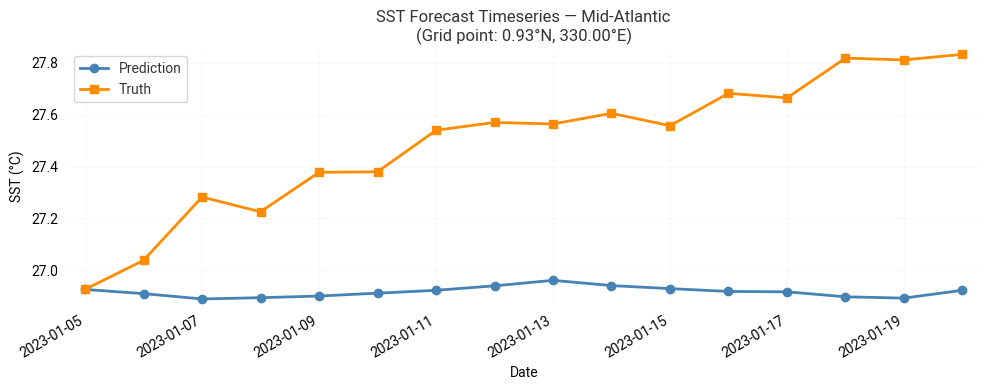

In [29]:
# --- Timeseries: mid-Atlantic point (0°N, 330°E ≈ 30°W) ---
target_lat, target_lon = 0.0, 330.0
dist        = np.sqrt((lats - target_lat)**2 + (lons - target_lon)**2)
nearest_idx = np.argmin(dist)
actual_lat  = lats[nearest_idx]
actual_lon  = lons[nearest_idx]

sst_pred_ts  = sst_pred[:, nearest_idx]  - 273.15   # °C
sst_truth_ts = sst_truth[:, nearest_idx] - 273.15

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(forecast_dates, sst_pred_ts,  marker='o', linewidth=2, color='steelblue', label='Prediction')
ax.plot(forecast_dates, sst_truth_ts, marker='s', linewidth=2, color='darkorange', label='Truth')
ax.set_xlabel('Date')
ax.set_ylabel('SST (°C)')
ax.set_title(
    f'SST Forecast Timeseries — Mid-Atlantic\n'
    f'(Grid point: {actual_lat:.2f}°N, {actual_lon:.2f}°E)',
    fontsize=12
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Tasks

Firstly, you can investigate simple inference changes, such as plotting for a different date, by editing inference_ToySST.yaml

As well as the final checkpoint, the model ouputs checkpoints throughout training. You can point to these intermediate checkpoints by editing inference_ToySST.yaml (you can find a list of checkpoints at `./pretrained_outputs/checkpoint/4438386d8b894aa59beb57bb1c7e0b85/`, use the ones beginning with inference....), create predictions from these and plot them to see how the predictions change throughout the training process.

Then you can carry out the same procedure as shown here for the models you've trained yourself using training_toySST.ipynb. To do this, point to the ckpt (checkpoint) files created by your own runs in the inference_ToySST.yaml (these checkpoints will be in new_training_outputs/...).

